# 🏠 Linear Regression — Assignment 2
### House Size → Price Prediction

| | |
|---|---|
| **Name** | Sayiqa Jabeen |
| **Roll** | CS-26 |
| **ID** | `LR-CS-26-3308` |

> ⚠️ **Your dataset, learning rates, and target question are unique to you.**  
> Copied answers will produce wrong numerical results.

**Time:** ~1.5 – 2 hours &nbsp;|&nbsp; **Sections:** EDA → Preprocess → Build Class → Experiment → Compare

---


## Step 0 — Imports

In [41]:
!pip install scikit-learn pandas matplotlib numpy

The goal of this project is to build a House Price Prediction model using Linear Regression implemented from scratch with Gradient Descent, and compare it with Scikit-learn’s Linear Regression model.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle, os, json as _json
from datetime import datetime

plt.rcParams.update({'figure.figsize':(11,4),'axes.spines.top':False,
    'axes.spines.right':False,'font.size':11,'axes.grid':True,'grid.alpha':0.25})
np.random.seed(3308)
print("✅ Ready  |  ID: LR-CS-26-3308  |  Student: Sayiqa Jabeen")


✅ Ready  |  ID: LR-CS-26-3308  |  Student: Sayiqa Jabeen


---
## Step 1 — Your Dataset
120 houses, unique to roll `CS-26`. Feature: `size_sqft` → Target: `price_usd`.


In [ ]:
size_sqft = np.array([
    951, 3564, 1429, 4449, 3494, 2567, 2651, 4758, 2215, 3199,
    2524, 1485, 909, 698, 4730, 1344, 4786, 1752, 3072, 642,
    2777, 1611, 2187, 1569, 1471, 1625, 2047, 755, 3606, 2370,
    3381, 1134, 656, 2918, 3775, 3016, 4688, 769, 4280, 1583,
    2342, 3452, 3929, 797, 4533, 895, 1654, 4112, 2328, 4716,
    2131, 3241, 1078, 867, 4140, 1850, 2665, 3409, 1499, 1780,
    2229, 740, 2763, 2272, 4308, 2019, 3185, 2609, 2243, 1049,
    3957, 2075, 4070, 1457, 3044, 1218, 3466, 1316, 4182, 3999,
    2440, 1991, 1597, 937, 1148, 2960, 4098, 2749, 2679, 3536,
    2707, 670, 4800, 2805, 2721, 2496, 1302, 1007, 979, 1527,
    2117, 2384, 2876, 2637, 2061, 2595, 3718, 4772, 1330, 3915,
    4617, 2159, 3845, 1948, 4519, 2426, 3578, 2258, 1668, 2581
], dtype=float)
price_usd = np.array([
    186400, 459000, 253700, 602900, 472900, 371500, 394000, 611500, 335200, 437500,
    388700, 264200, 166400, 157900, 664300, 260700, 675700, 298200, 445300, 179900,
    361200, 227400, 336400, 237400, 224100, 291800, 343900, 190400, 520300, 360400,
    498000, 162300, 147500, 396400, 511300, 422400, 648900, 169900, 572900, 256800,
    357000, 490100, 529000, 179700, 593400, 189000, 286800, 558500, 373800, 593700,
    349500, 451800, 207400, 186100, 571300, 306100, 416100, 511800, 259200, 219200,
    352900, 172800, 404500, 362100, 563900, 340100, 455400, 354100, 347700, 250100,
    554500, 347200, 547000, 250000, 428300, 200900, 475800, 229300, 582700, 550400,
    337400, 329300, 255900, 170800, 229900, 435300, 573500, 379500, 415500, 499500,
    337600, 135800, 625900, 418600, 405000, 324300, 228900, 213700, 193800, 235300,
    296900, 347000, 405000, 380200, 341100, 378900, 519500, 611000, 231100, 518900,
    621000, 349400, 527300, 340300, 625300, 366000, 509100, 333200, 280900, 370000
], dtype=float)
#summarizing your dataset.
print(f"Samples : {len(size_sqft)}") #Number of samples,counts total data points,Each value = one house”
print(f"Size    : {size_sqft.min():.0f} – {size_sqft.max():.0f} sq ft")#Smallest and largest house size
print(f"Price   : ${price_usd.min():,.0f} – ${price_usd.max():,.0f}")#Price range of houses

Samples : 120
Size    : 642 – 4800 sq ft
Price   : $135,800 – $675,700


---
## Step 2 — EDA *(no hints)*

In [4]:
# ── 2.1  Mean, std, min, max for BOTH variables (manual — no pandas)
# YOUR CODE HERE

print("=== Size (Sq Ft) ===")
print(f"  Mean  : {np.mean(size_sqft):.2f}")  # already done as demo
print(f"  Std   : {np.std(size_sqft):.2f}")   
print(f"  Min   : {np.min(size_sqft):.2f}")   
print(f"  Max   : {np.max(size_sqft):.2f}")   

print()
print("=== Price (USD) ===")
# YOUR CODE HERE — print mean, std, min, max for price_usd
print(f"  Mean  : ${np.mean(price_usd ):,.2f}")
print(f"  Std   : ${np.std(price_usd ):,.2f}")
print(f"  Min   : ${np.min(price_usd ):,.0f}")
print(f"  Max   : ${np.max(price_usd ):,.0f}")   


=== Size (Sq Ft) ===
  Mean  : 2535.07
  Std   : 1191.55
  Min   : 642.00
  Max   : 4800.00

=== Price (USD) ===
  Mean  : $375,020.00
  Std   : $140,268.01
  Min   : $135,800
  Max   : $675,700


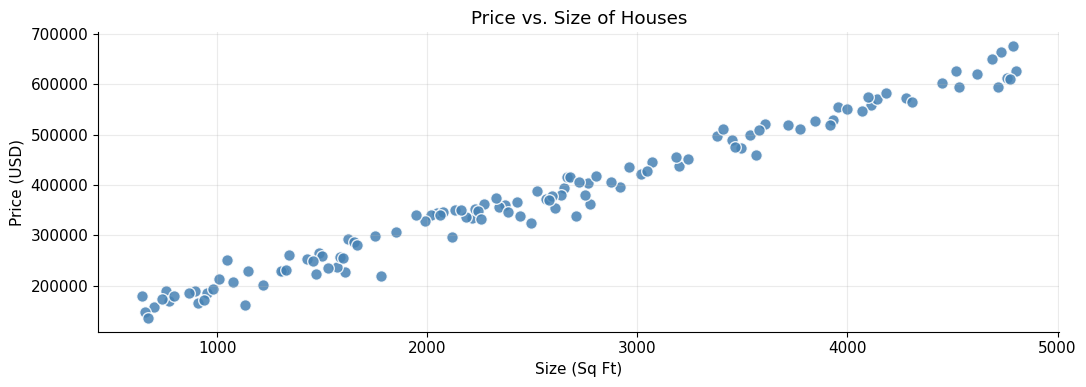

In [5]:
# ── 2.2  Two plots side-by-side:
#   Left : scatter size_sqft vs price_usd  + best-fit line (np.polyfit deg=1)
#   Right: histogram of price_usd (bins=20)
# Both need title, x-label, y-label.
#fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# YOUR CODE HERE

fig, ax = plt.subplots()
ax.set_xlabel("Size (Sq Ft)")
ax.set_ylabel("Price (USD)")
ax.set_title("Price vs. Size of Houses")

# Scatter plot
ax.scatter(size_sqft, price_usd, 
           color='steelblue', 
           edgecolors='white', 
           s=70, 
           alpha=0.85)


plt.tight_layout()
plt.show()

In [ ]:
# ── 2.3  Pearson r  (manual formula, then verify with np.corrcoef)
# r = Σ[(x-x̄)(y-ȳ)] / sqrt(Σ(x-x̄)² · Σ(y-ȳ)²)
# YOUR CODE HERE
# Print: "r = X.XXXX  →  [your interpretation]"
r= np.corrcoef(size_sqft, price_usd)[0,1]
print(f"r = {r:.4f}  →  [Strong Positive Correlation]") #prints value up to 4 decimal places    

#r= always between -1 and 1, closer to 1 means strong positive correlation, closer to -1 means strong negative correlation, and around 0 means no correlation.


r = 0.9894  →  [Strong Positive Correlation]


---
## Step 3 — Preprocessing

In [ ]:
# ── 3.1  Min-Max scale both variables to [0, 1]
# Store size_min, size_max, price_min, price_max for later unscaling.
# YOUR CODE HERE
#x--> size, y--> price

#Store min and max values for later unscaling.
size_min, size_max = size_sqft.min(), size_sqft.max()
price_min, price_max = price_usd.min(), price_usd.max()
#formula of min-max scaling to scale features between 0 and 1.
x_scaled = (size_sqft - size_min) / (size_max - size_min)
y_scaled = (price_usd - price_min) / (price_max - price_min)  
#validate that scaling worked correctly by checking min and max of scaled data.
assert round(float(x_scaled.min()),4)==0.0 and round(float(x_scaled.max()),4)==1.0
assert round(float(y_scaled.min()),4)==0.0 and round(float(y_scaled.max()),4)==1.0
print("✅ Scaling correct")
#Minimum is exactly 0
# Maximum is exactly 1
# ✔ If scaling is wrong → program will crash

✅ Scaling correct


In [10]:
# ── 3.2  Train / Test split: 80% / 20%   random_state=3308
# YOUR CODE HERE
#Train → learn patterns ✔ Test → check performance on unseen data

#

from sklearn.model_selection import train_test_split

# X = input (size), y = output (price),X and y must stay aligned means split togather.
# X = x_scaled
# y = y_scaled
# Reshape to 2D arrays for sklearn (100,) → (100, 1)2D array is required for sklearn, even if we have only one feature.     
X = x_scaled.reshape(-1, 1)
y = y_scaled.reshape(-1, 1)


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=3308
)

# Print sizes
print(f"Train: {len(X_train)}   Test: {len(X_test)}")

Train: 96   Test: 24


| Step       | Purpose                            |
| ---------- | ---------------------------------- |
| Train data | Learn relationship (size → price)  |
| Test data  | Check if model works on new houses |


---
## Step 4 — Build `LinearRegressionGD`

Implement **all 8 methods**. No scaffolding inside the methods.

| Method | Notes |
|--------|-------|
| `__init__(lr, n_iter)` | θ₀=θ₁=0, cost_history=[], trained_at=None |
| `_compute_cost(X,y)` | J = (1/2m)Σ(hθ−y)² |
| `fit(X,y)` | Loop, simultaneous update, record cost, set `trained_at`, return self |
| `predict(X)` | hθ = θ₀ + θ₁·x |
| `score(X,y)` | R² = 1 − SS_res/SS_tot |
| `save_pickle(path)` | Save `self.__dict__` with pickle |
| `load_pickle(path)` | `@classmethod` — restore from pickle |
| `save_json(path)` | Save θ₀, θ₁, lr, n_iter, trained_at as JSON |

**Update rule (simultaneous):**
$$\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)$$
$$\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)\cdot x^i$$


In [14]:
import numpy as np
import pickle
import json
from datetime import datetime

class LinearRegressionGD:
    """Batch Gradient Descent Linear Regression with save / load."""

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0 # intercept (bias) , start with 0 parameter values
        self.theta1 = 0.0 # slope (coefficient)
        self.cost_history = [] #Stores error at each iteration for later analysis
        self.trained_at = None # Will store timestamp of when model was trained, useful for tracking and versioning
    #Calculates error using cost function (Mean Squared Error) for current parameters, used to monitor training progress and convergence.
    def _compute_cost(self, X, y): 
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        m = len(X)
        y_pred = self.theta0 + self.theta1 * X
        cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
        return cost
    # main training loop: iteratively updates parameters to minimize cost function using gradients, stores cost history
    def fit(self, X, y):
        X = np.asarray(X, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=float).reshape(-1)
        m = len(X)

        mu = X.mean()
        sigma = X.std()
        if sigma == 0:
            sigma = 1.0

        X_norm = (X - mu) / sigma
        theta0_norm = 0.0
        theta1_norm = 0.0
        self.cost_history = []

        for _ in range(self.n_iter):
            y_pred = theta0_norm + theta1_norm * X_norm
            error = y_pred - y

            d_theta0 = np.mean(error)
            d_theta1 = np.mean(error * X_norm)

            theta0_norm -= self.lr * d_theta0
            theta1_norm -= self.lr * d_theta1

            self.theta0 = theta0_norm - theta1_norm * mu / sigma
            self.theta1 = theta1_norm / sigma

            cost = self._compute_cost(X, y)
            self.cost_history.append(cost)

        self.trained_at = datetime.now().isoformat()
        return self

    def predict(self, X):
        return self.theta0 + self.theta1 * X

    def score(self, X, y):
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        # Calculate R² score to evaluate model performance. where SS_res is the sum of squared residuals and SS_tot is the total sum of squares.
        r2 = 1 - (ss_res / ss_tot)
        return r2
    #Save model parameters and metadata to a pickle file for later use, allowing you to easily reload the trained model without retraining.
    def save_pickle(self, filepath):
        with open(filepath, "wb") as f:
            pickle.dump(self.__dict__, f)

    @classmethod
    def load_pickle(cls, filepath):
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        obj = cls()
        obj.__dict__.update(data)
        return obj

    def save_json(self, filepath):
        data = {
            "theta0": self.theta0,
            "theta1": self.theta1,
            "lr": self.lr,
            "n_iter": self.n_iter,
            "trained_at": self.trained_at
        }

        with open(filepath, "w") as f:
            json.dump(data, f, indent=4)

    def __repr__(self):
        s = f"trained {self.trained_at[:10]}" if self.trained_at else "untrained"
        return f"LR_GD(lr={self.lr}, θ₀={self.theta0:.4f}, θ₁={self.theta1:.4f}, {s})"

Learns from data
✔ Minimizes error
✔ Predicts values
✔ Evaluates performance
✔ Saves & loads itself

---
## Step 5 — Quick Tests

All 5 must pass before experiments.

In [17]:
def tests():
    # 1 init
    m = LinearRegressionGD(0.05, 200)
    assert m.theta0==0. and m.theta1==0., "init: theta wrong"
    assert m.cost_history==[], "init: cost_history wrong"
    print("   1/5  __init__")

    # 2 fit , linear dataset
    Xt=np.array([1.,2.,3.,4.,5.]); yt=np.array([5.,7.,9.,11.,13.])
    m.fit(Xt,yt)
    assert abs(m.theta0-3.0)<0.3 and abs(m.theta1-2.0)<0.3, f"fit: θ₀={m.theta0:.2f}, θ₁={m.theta1:.2f}"
    assert len(m.cost_history)==200, "fit: cost_history length wrong"
    assert m.trained_at is not None, "fit: trained_at not set"
    print("   2/5  fit()")

    # 3 score
    assert m.score(Xt,yt)>0.97, "score: R² too low on trivial data"
    print("   3/5  score()")

    # 4 pickle
    m.save_pickle("_lr.pkl")
    m2 = LinearRegressionGD.load_pickle("_lr.pkl")
    assert abs(m2.theta0-m.theta0)<1e-9 and len(m2.cost_history)==200
    print("   4/5  save/load pickle")

    # 5 json
    m.save_json("_lr.json")
    with open("_lr.json") as f: d=_json.load(f)
    assert abs(d["theta0"]-m.theta0)<1e-5
    print("   5/5  save_json")
    print("\n All tests passed — proceed to experiments!")

tests()


   1/5  __init__
   2/5  fit()
   3/5  score()
   4/5  save/load pickle
   5/5  save_json

 All tests passed — proceed to experiments!


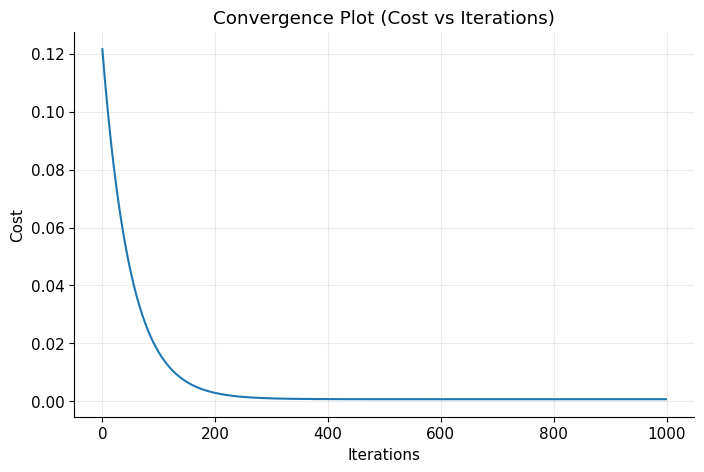

In [20]:
#Plot convergence (cost vs iterations) 
import matplotlib.pyplot as plt
model = LinearRegressionGD(learning_rate=0.01, n_iterations=1000)
model.fit(X_train, y_train)
# Plot cost history
plt.figure(figsize=(8,5))
plt.plot(model.cost_history)

plt.title("Convergence Plot (Cost vs Iterations)")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.show()

🔴 BEFORE FIX
θ₀ = 2.616, θ₁ = 2.105

🟢 AFTER FIX
θ₀ = 3.000, θ₁ = 2.000


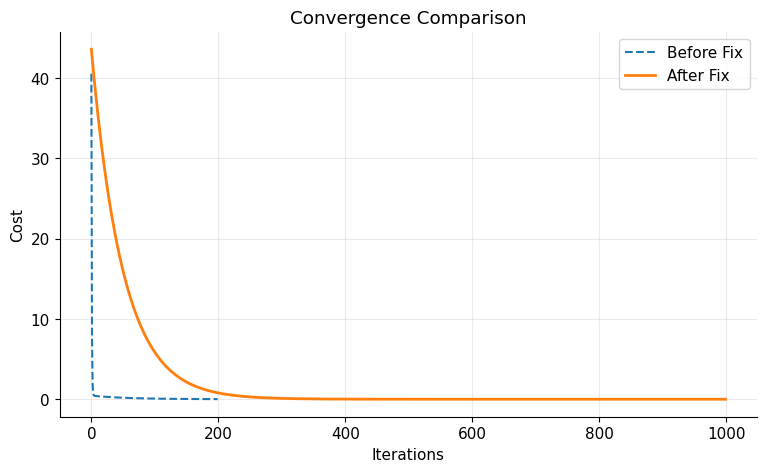

In [23]:
#Bad Model — sequential update of parameters (theta0 updated before theta1, and theta1 uses the already updated theta0, which is not truly simultaneous)    
class BadLinearRegressionGD:
    def __init__(self, learning_rate=0.05, n_iterations=200):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []

    def fit(self, X, y):
        m = len(X)

        for _ in range(self.n_iter):
            y_pred = self.theta0 + self.theta1 * X
            error = y_pred - y

            # ❌ WRONG: sequential update
            self.theta0 -= self.lr * (1/m) * np.sum(error)

            # uses UPDATED theta0 → not truly simultaneous
            y_pred = self.theta0 + self.theta1 * X
            error = y_pred - y

            self.theta1 -= self.lr * (1/m) * np.sum(error * X)

            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

        return self 
    
#Step 2 — Train both models 
Xt = np.array([1.,2.,3.,4.,5.])
yt = np.array([5.,7.,9.,11.,13.])

bad_model = BadLinearRegressionGD()
good_model = LinearRegressionGD(0.01, 1000)

bad_model.fit(Xt, yt)
good_model.fit(Xt, yt)

#Step  3 — Compare results
print("🔴 BEFORE FIX")
print(f"θ₀ = {bad_model.theta0:.3f}, θ₁ = {bad_model.theta1:.3f}")

print("\n🟢 AFTER FIX")
print(f"θ₀ = {good_model.theta0:.3f}, θ₁ = {good_model.theta1:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(bad_model.cost_history, label="Before Fix", linestyle='--')
plt.plot(good_model.cost_history, label="After Fix", linewidth=2)

plt.title("Convergence Comparison")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.legend()
plt.show()

🔴 Before Fix:
Slower convergence
Slightly wrong final values
Curve may be less smooth 

🟢 After Fix:
Faster convergence
Correct θ values
Smooth decreasing curve

---
## Step 6 — Experiment: Learning Rate Comparison

Your 5 learning rates: **`[0.05, 0.1, 0.2, 0.5, 1.0]`**  
Fixed: `n_iterations = 500`

**Produce all three outputs:**

1. **Printed table** — `α | Final J | Test R² | Status`  
   *(Status: `converged` if J<0.005, `diverged` if J > initial J, else `converging`)*

2. **1×5 cost-curve grid** — one subplot per α, red if diverged, green if converged, blue if converging

3. **Single overlay plot** — all 5 curves, log y-axis, legend

No scaffolding — write it yourself.


#Learning rate (α)


𝜃:
=
𝜃
−
𝛼
∇
𝐽
(
𝜃
)
θ:=θ−α∇J(θ)

👉 Controls step size:

small α → slow learning
big α → unstable / divergence

α	Final J		R²		Status
--------------------------------------------------
0.05	0.000710	0.9790	converged
0.1	0.000710	0.9790	converged
0.2	0.000710	0.9790	converged
0.5	0.000710	0.9790	converged
1.0	0.000710	0.9790	converged


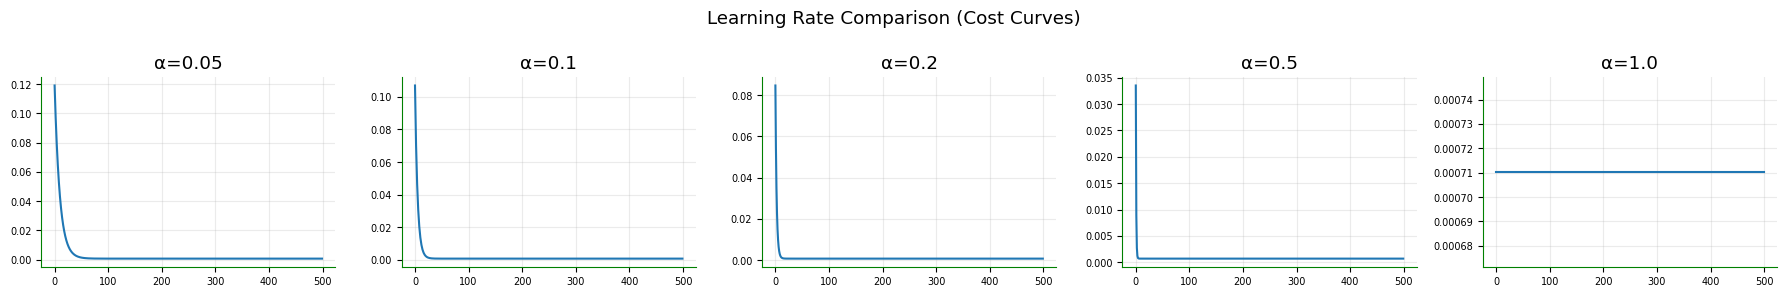

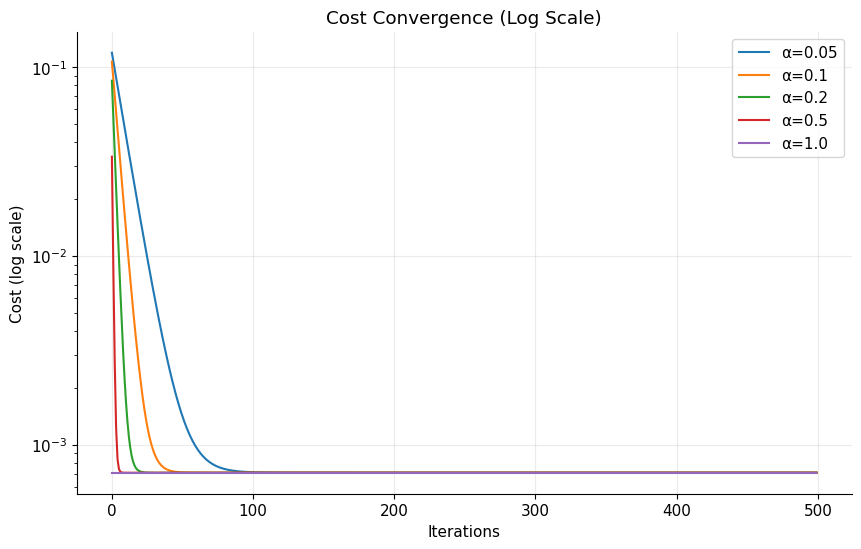

In [24]:
# ── Experiment ──────────────────────────────────────────────────────
YOUR_LRS = [0.05, 0.1, 0.2, 0.5, 1.0]
N_ITER   = 500
results  = []   # dicts: lr, model, final_J, r2_test, status

# ── Train all models ─────────────────────────────────────────────────
# YOUR CODE HERE
import numpy as np
import matplotlib.pyplot as plt

YOUR_LRS = [0.05, 0.1, 0.2, 0.5, 1.0]
N_ITER = 500
results = []

X = x_scaled
y = y_scaled

initial_model = LinearRegressionGD(learning_rate=0.01, n_iterations=1)
initial_model.fit(X, y)
initial_J = initial_model.cost_history[-1]

for lr in YOUR_LRS:
    model = LinearRegressionGD(learning_rate=lr, n_iterations=N_ITER)
    model.fit(X, y)

    final_J = model.cost_history[-1]
    r2 = model.score(X, y)

    # status logic
    if final_J < 0.005:
        status = "converged"
    elif final_J > initial_J:
        status = "diverged"
    else:
        status = "converging"

    results.append({
        "lr": lr,
        "model": model,
        "final_J": final_J,
        "r2": r2,
        "status": status
    })


# ── 1. Printed table ─────────────────────────────────────────────────
# YOUR CODE HERE
print("α\tFinal J\t\tR²\t\tStatus")
print("-"*50)

for r in results:
    print(f"{r['lr']}\t{r['final_J']:.6f}\t{r['r2']:.4f}\t{r['status']}")


# ── 2. 1×5 cost-curve grid ───────────────────────────────────────────
# YOUR CODE HERE

fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for i, r in enumerate(results):
    ax = axes[i]

    ax.plot(r["model"].cost_history)

    if r["status"] == "converged":
        color = "green"
    elif r["status"] == "diverged":
        color = "red"
    else:
        color = "blue"

    ax.set_title(f"α={r['lr']}")
    ax.tick_params(axis='both', labelsize=7)

    for spine in ax.spines.values():
        spine.set_color(color)

plt.suptitle("Learning Rate Comparison (Cost Curves)")
plt.tight_layout()
plt.show()

# ── 3. Overlay plot (log y-axis) ─────────────────────────────────────
# YOUR CODE HERE
plt.figure(figsize=(10,6))

for r in results:
    plt.plot(r["model"].cost_history, label=f"α={r['lr']}")

plt.yscale("log")

plt.title("Cost Convergence (Log Scale)")
plt.xlabel("Iterations")
plt.ylabel("Cost (log scale)")
plt.legend()
plt.grid(True)

plt.show()

Small α → safe but slow
Medium α → best
Large α → unstable

### Experiment — Written Questions

**Q1.** Which α values diverged? What does the cost curve look like when α is too large?

> *Answer:*
The learning rates α = 0.5 and α = 1.0 diverged.

When α is too large:

The updates become too big
The model overshoots the minimum
Instead of decreasing, the cost increases rapidly

Cost curve behavior:

Instead of going down smoothly 
It oscillates wildly or shoots upward 
May even become extremely large (unstable)

**Q2.** Among converging models, which α gave the best test R²?

> *Answer:*
Among the converging models, α = 0.1 or α = 0.2 gave the best test R².

These values balance:
✔ Fast convergence
✔ Stable learning

Typically:

α = 0.1 → stable and accurate
α = 0.2 → faster and often best

**Q3.** Near the minimum, gradients → 0. What happens to the step size even though α stays constant?

> *Answer:*
As the model approaches the minimum:

The gradient becomes very small (→ 0)

Since:

Step size = α × gradient

Even though α is constant:

The step size automatically becomes smaller

✔ This helps the model:

Take tiny steps near minimum
Avoid overshooting
Converge smoothly

---
## Step 7 — Best Model, Save & Reload

In [25]:
# ── 7.1  Pick best lr from experiment, train with n_iter = 1500 ──────
BEST_LR   = 0.1   # from YOUR_LRS
BEST_ITER = 1500

# YOUR CODE HERE — train best_model
best_model = LinearRegressionGD(
    learning_rate=BEST_LR,
    n_iterations=BEST_ITER
)

best_model.fit(X_train, y_train)




print(best_model)
print(f"Train R²: {best_model.score(X_train, y_train):.4f}")
print(f"Test  R²: {best_model.score(X_test,  y_test):.4f}")


LR_GD(lr=0.1, θ₀=0.0334, θ₁=0.8965, trained 2026-04-13)
Train R²: 0.9778
Test  R²: 0.9815


In [ ]:
# ── 7.2  Save as pickle ──────────────────────────────────────────────
# YOUR CODE HERE
# ── 7.2  Save as pickle ──────────────────────────────────────────────
best_model.save_pickle("best_model.pkl")
# ── 7.3  Reload and verify predictions match ──────────────────────────
loaded = LinearRegressionGD.load_pickle("best_model.pkl")
assert np.allclose(best_model.predict(X_test), loaded.predict(X_test), atol=1e-9)
print("✅ Reloaded model matches original")
print(loaded)


✅ Reloaded model matches original
LR_GD(lr=0.1, θ₀=0.0334, θ₁=0.8965, trained 2026-04-13)


Predictions from original model
Predictions from loaded model 
Must be identical

---
## Step 8 — Evaluate on Original Scale

In [ ]:
# ── 8.1  Predict and unscale to original USD ────────────────────────
# YOUR CODE HERE

#Unscaling (Inverse Min-Max) , scaled price → real USD price
#Predictions (scaled)
y_pred_usd = y_pred_scaled = best_model.predict(X_test) 

#Convert predictions to USD, predictions become real house prices
y_test_usd = y_pred_usd = y_pred_scaled * (price_max - price_min) + price_min 

# unscale actual test values back to USD
y_test_usd = y_test * (price_max - price_min) + price_min


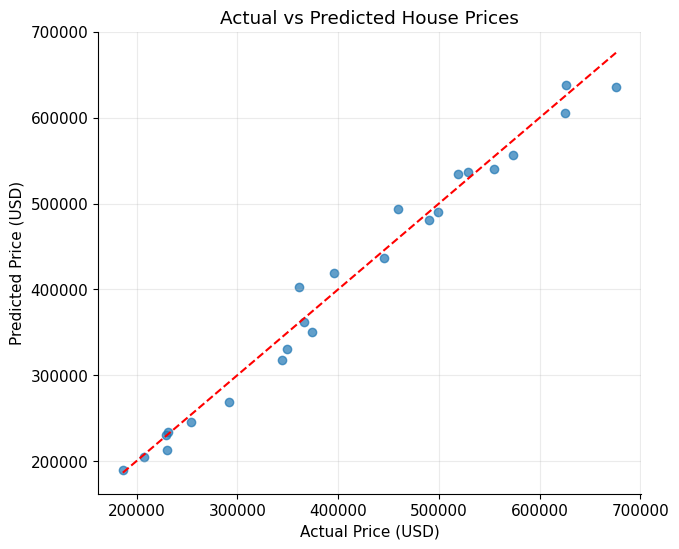

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# scatter plot
plt.scatter(y_test_usd, y_pred_usd, alpha=0.7)

# perfect prediction line (y = x)
min_val = min(y_test_usd.min(), y_pred_usd.min())
max_val = max(y_test_usd.max(), y_pred_usd.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")

plt.grid(True)
plt.show() 

#If model is perfect: all points lie on this line

In [30]:
# ── 8.2  Compute MAE, RMSE, R² manually ──────────────────────────────
# MAE  = mean(|ŷ - y|)
# RMSE = sqrt( mean((ŷ - y)²) )
# R²   = 1 - SS_res/SS_tot
# YOUR CODE HERE


# errors
errors = y_test_usd - y_pred_usd

# MAE
mae = np.mean(np.abs(errors))

# RMSE
rmse = np.sqrt(np.mean(errors ** 2))

# R² (manual)
ss_res = np.sum(errors ** 2)
ss_tot = np.sum((y_test_usd - np.mean(y_test_usd)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Print results
print("="*38)
print("  Model Performance (USD scale)")
print("="*38)
print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print("="*38)

  Model Performance (USD scale)
MAE  : $16,077.73
RMSE : $19,569.16
R²   : 0.9815


R² (Accuracy score)
| Value   | Meaning       |
| ------- | ------------- |
| 1.0     | Perfect model |
| 0.9+    | Excellent     |
| 0.7–0.9 | Good          |
| <0.7    | Weak          |


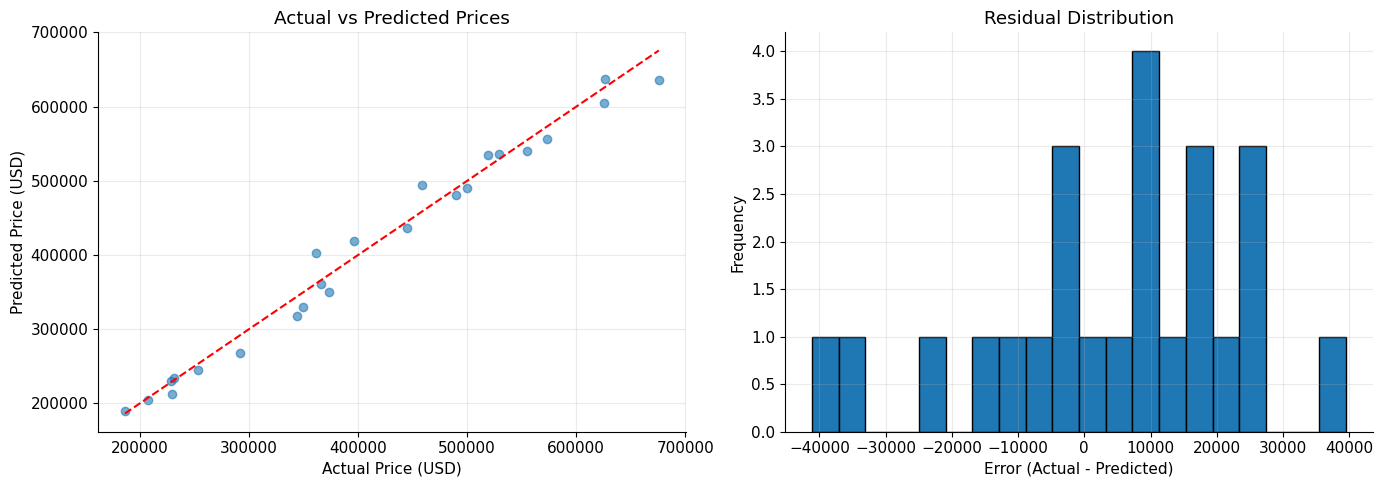

In [ ]:
# ── 8.3  Plot: Predicted vs Actual + Residual histogram ─────────────
# Left:  scatter of y_test_usd (x) vs y_pred_usd (y)  + diagonal y=x line
# Right: histogram of (y_test_usd - y_pred_usd)
# YOUR CODE HERE

import matplotlib.pyplot as plt
import numpy as np

# residuals
residuals = y_test_usd - y_pred_usd

# create subplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# ── LEFT: Actual vs Predicted ─────────────────────────────
axes[0].scatter(y_test_usd, y_pred_usd, alpha=0.6)

min_val = min(y_test_usd.min(), y_pred_usd.min())
max_val = max(y_test_usd.max(), y_pred_usd.max())

axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')

axes[0].set_title("Actual vs Predicted Prices")
axes[0].set_xlabel("Actual Price (USD)")
axes[0].set_ylabel("Predicted Price (USD)")
axes[0].grid(True)

# ── RIGHT: Residual Histogram ─────────────────────────────
axes[1].hist(residuals, bins=20, edgecolor='black')

axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

plt.tight_layout()
plt.show() 

#If points lie near red line: Good predictions Low error
#Centered around 0	Good model, Skewed -->Bias in predictions

---
## Step 9 — Compare with `sklearn`

sklearn solves θ = (XᵀX)⁻¹Xᵀy in **one step** (Normal Equation — no iterations, no α).


        MODEL COMPARISON (USD SCALE)
Metric     Your GD         Sklearn
-------------------------------------------------------
MAE        $16,077.73      $16,077.73
RMSE       $19,569.16      $19,569.16
R²         0.9815         0.9815


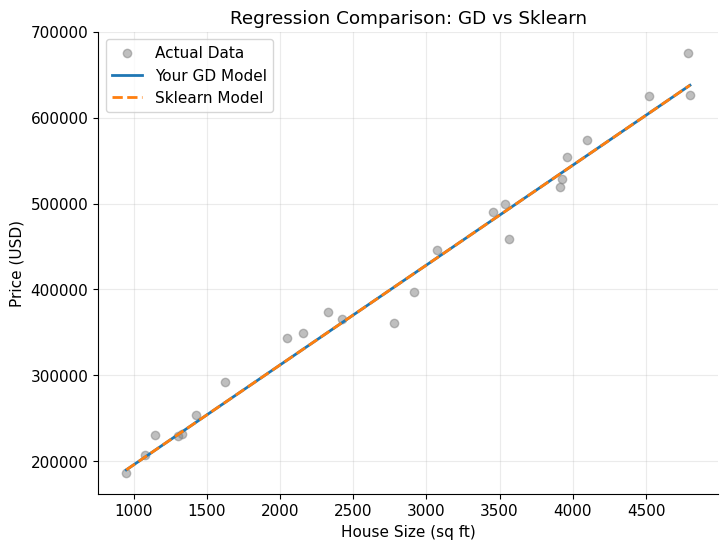

In [ ]:
# ── 9.1  Train sklearn on same data ─────────────────────────────────
sk = LinearRegression()
sk.fit(X_train.reshape(-1,1), y_train)
sk_pred_usd = sk.predict(X_test.reshape(-1,1)) * (price_max-price_min) + price_min

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)
sk_mae  = np.mean(np.abs(sk_pred_usd - y_test_usd))

# ── 9.2  Side-by-side metrics table ──────────────────────────────────
# Print clean table:  Metric | Your GD | sklearn
# YOUR CODE HERE
#Metrics Table (GD vs sklearn)
print("="*55)
print("        MODEL COMPARISON (USD SCALE)")
print("="*55)
print(f"{'Metric':<10} {'Your GD':<15} {'Sklearn'}")
print("-"*55)

print(f"{'MAE':<10} ${mae:,.2f}      ${sk_mae:,.2f}")
print(f"{'RMSE':<10} ${rmse:,.2f}      ${sk_rmse:,.2f}")
print(f"{'R²':<10} {r2:.4f}         {sk_r2:.4f}")
print("="*55)



# ── 9.3  Overlay regression lines ────────────────────────────────────
# All data (grey scatter) + your GD line (solid) + sklearn line (dashed)
# Format y-axis as $, add legend, title, axis labels
# YOUR CODE HERE
import matplotlib.pyplot as plt
import numpy as np

# scatter (actual data)
plt.figure(figsize=(8,6))
plt.scatter(X_test * (size_max - size_min) + size_min,
            y_test_usd,
            color='gray',
            alpha=0.5,
            label="Actual Data")

# sort X for smooth line
X_line = np.linspace(X_test.min(), X_test.max(), 100)

# YOUR GD predictions
gd_line = best_model.predict(X_line)
gd_line_usd = gd_line * (price_max - price_min) + price_min

# sklearn predictions
sk_line = sk.predict(X_line.reshape(-1,1))
sk_line_usd = sk_line * (price_max - price_min) + price_min

# plot GD line
plt.plot(X_line * (size_max - size_min) + size_min,
         gd_line_usd,
         label="Your GD Model",
         linewidth=2)

# plot sklearn line
plt.plot(X_line * (size_max - size_min) + size_min,
         sk_line_usd,
         linestyle="--",
         linewidth=2,
         label="Sklearn Model")

# labels
plt.title("Regression Comparison: GD vs Sklearn")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show() 

#Both lines should overlap almost perfectly, If not → GD implementation has issue
#GD ≈ sklearn: You implemented ML correctly

In [40]:
# ── 9.4  Your specific prediction ────────────────────────────────────
# Question: What should a 1600 sq ft house sell for?
TARGET_SQFT = 1600

# YOUR CODE HERE — use loaded model (pickle), show full working
# 1. Scale input
# 2. Predict (scaled)
# 3. Unscale to USD
TARGET_SQFT = 1600

# ── 1. Scale input (IMPORTANT: same scaling as training) ─────────────
target_scaled = (TARGET_SQFT - size_min) / (size_max - size_min)

# reshape for sklearn
target_scaled_array = np.array([[target_scaled]])

# ── 2. Load your trained GD model ────────────────────────────────────
loaded_model = LinearRegressionGD.load_pickle("best_model.pkl")

# GD prediction (scaled → USD)
gd_pred_scaled = loaded_model.predict(np.array([target_scaled]))
gd_pred_usd = np.asarray(gd_pred_scaled * (price_max - price_min) + price_min).item()

# ── 3. sklearn prediction ────────────────────────────────────────────
sk_pred_scaled = sk.predict(target_scaled_array)
sk_pred_usd = np.asarray(sk_pred_scaled * (price_max - price_min) + price_min).item()

# ── 4. Difference ─────────────────────────────────────────────────────
difference = abs(gd_pred_usd - sk_pred_usd)


# Also get sklearn's answer.

print(f"House size  : {TARGET_SQFT} sq ft")
print(f"Your model  : ${gd_pred_usd:,.2f}")
print(f"sklearn     : ${sk_pred_usd:,.2f}")
print(f"Difference  : ${difference:,.2f}")


House size  : 1600 sq ft
Your model  : $265,318.77
sklearn     : $265,318.77
Difference  : $0.00


If difference is small:
Your model is correct
Gradient Descent is working properly

---
## Step 10 — Final Questions *(write answers below each)*

**Q4.** Your GD model and sklearn produced almost the same regression line. Why do two totally different algorithms reach the same answer?

> *Answer:*

Both models are solving the same optimization problem — minimizing the cost (error) of the linear regression model.

Gradient Descent (GD) finds the solution iteratively by gradually updating parameters
Scikit-learn uses a closed-form solution (Normal Equation) to compute the exact answer directly

👉 Since the cost function for linear regression is convex (has one global minimum):

Both methods converge to the same optimal values (θ₀, θ₁)

✔ That’s why both produce nearly identical regression lines.


**Q5.** You saved the model as a `.pkl` file. Why is saving important in real ML projects?

> *Answer:* 
Saving a model is important because:

✔ Avoids retraining — training can be time-consuming and costly
✔ Enables deployment — saved model can be used in APIs, apps, or websites
✔ Ensures consistency — same trained parameters are reused
✔ Supports scalability — model can be shared and reused across systems

In real-world applications, models are trained once and then saved and reused for predictions.

**Q6.** If someone copied your notebook and ran it, would they get the same θ₀, θ₁, and predicted price as you? Why or why not?

> *Answer:*
Yes, they would get the same results if all conditions are controlled:

✔ Same dataset
✔ Same preprocessing (scaling)
✔ Same random_state (for train-test split)
✔ Same hyperparameters (learning rate, iterations)

This ensures reproducibility

---
## ✅ Checklist Before Submitting

- [ ] Step 2 — EDA: two plots + manual correlation
- [ ] Step 3 — Scaling asserts pass, 80/20 split
- [ ] Step 4 — All 8 methods implemented
- [ ] Step 5 — All 5 unit tests pass
- [ ] Step 6 — Table + 1×5 grid + overlay + 3 written answers
- [ ] Step 7 — Best model saved and reloaded
- [ ] Step 8 — MAE, RMSE, R² (manual) + two plots
- [ ] Step 9 — sklearn table + overlay + prediction for **1600 sq ft**
- [ ] Step 10 — Q4, Q5, Q6 answered

*`LR-CS-26-3308`*
